# PRCP-1016 — Heart Disease Prediction

## Project Overview

**Domain:** Healthcare  
**Objective:** Predict whether `heart_disease_present` is 0 (no heart disease) or 1 (heart disease present).

This notebook completes all three project tasks:

1. **Data Analysis:** data understanding, quality checks, exploratory analysis and interpretation.
2. **Machine Learning:** development and comparison of six classification algorithms, 5-fold cross-validation, hyperparameter tuning and final evaluation.
3. **Hospital Recommendations:** practical recommendations for using predictions as a decision-support/triage aid while keeping final clinical decisions with qualified healthcare professionals.

> **Important limitation:** This is an academic machine-learning project using a small dataset of 180 patient records. The resulting model must not be treated as a clinically validated diagnostic system. External validation, calibration, threshold selection and appropriate clinical governance would be required before any real-world use.

---

## Problem Statement

Cardiovascular diseases are a major global health burden. The project dataset contains cardiovascular measurements that can be used to investigate whether a patient is likely to have heart disease. The target variable is `heart_disease_present`, where **0 = no heart disease** and **1 = heart disease present**.

The goal is to build a reliable binary classification workflow, compare multiple machine-learning algorithms, select a defensible candidate model for production-oriented experimentation, and provide hospital recommendations for early risk identification.

### Dataset source

The project brief identifies the dataset as part of DrivenData's **Predicting Heart Disease / Machine Learning with a Heart** challenge. The supplied data are split into `values.csv` and `labels.csv`, joined using `patient_id`.

# 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# 3. Load Dataset

In [2]:
values = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

print("Values shape:", values.shape)
print("Labels shape:", labels.shape)

Values shape: (180, 14)
Labels shape: (180, 2)


In [3]:
display(values.head())
display(labels.head())

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


### Combine the Datasets

In [4]:
df = pd.merge(values, labels, on="patient_id")
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


# 4. Data Understanding

In [5]:
df.shape

(180, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [7]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [8]:
df.dtypes

patient_id                               object
slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
heart_disease_present                     int64
dtype: object

### Target Variable Distribution

heart_disease_present
0    100
1     80
Name: count, dtype: int64


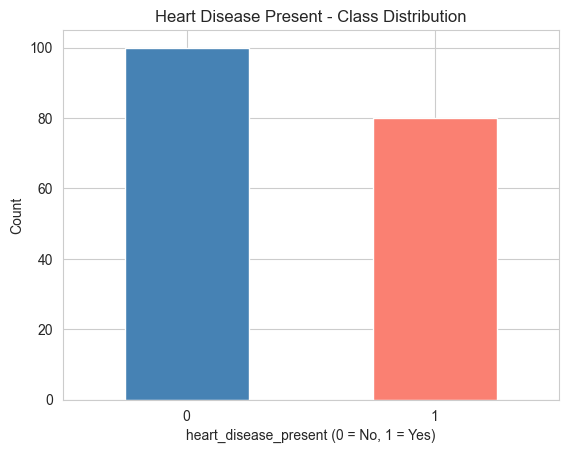

In [9]:
print(df["heart_disease_present"].value_counts())
df["heart_disease_present"].value_counts().plot(kind="bar", color=["steelblue","salmon"])
plt.title("Heart Disease Present - Class Distribution")
plt.xlabel("heart_disease_present (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# 5. Data Cleaning

* Checking for missing values, duplicate rows, and duplicate patient IDs.

In [10]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate patient_id:", df["patient_id"].duplicated().sum())

Duplicate rows: 0
Duplicate patient_id: 0


### Data Cleaning Findings

- **Missing values:** none were found.
- **Duplicate rows:** none were found.
- **Duplicate patient IDs:** none were found; `patient_id` uniquely identifies each record.
- **Identifier handling:** `patient_id` is excluded from the predictive feature matrix because it is a random identifier rather than a clinical measurement.
- **Categorical data:** `thal` is the categorical feature and is encoded after the train/test split to prevent leakage.

**Conclusion:** The dataset is already structurally clean, so no imputation or duplicate-removal procedure is required. The main preprocessing requirements are categorical encoding and numerical scaling.

In [12]:
# Drop the identifier column - not a predictive feature
X_full = df.drop(columns=["patient_id", "heart_disease_present"])
y = df["heart_disease_present"]
print("Feature matrix shape:", X_full.shape)

Feature matrix shape: (180, 13)


# 6. Exploratory Data Analysis

### 1. Numerical Feature Distributions

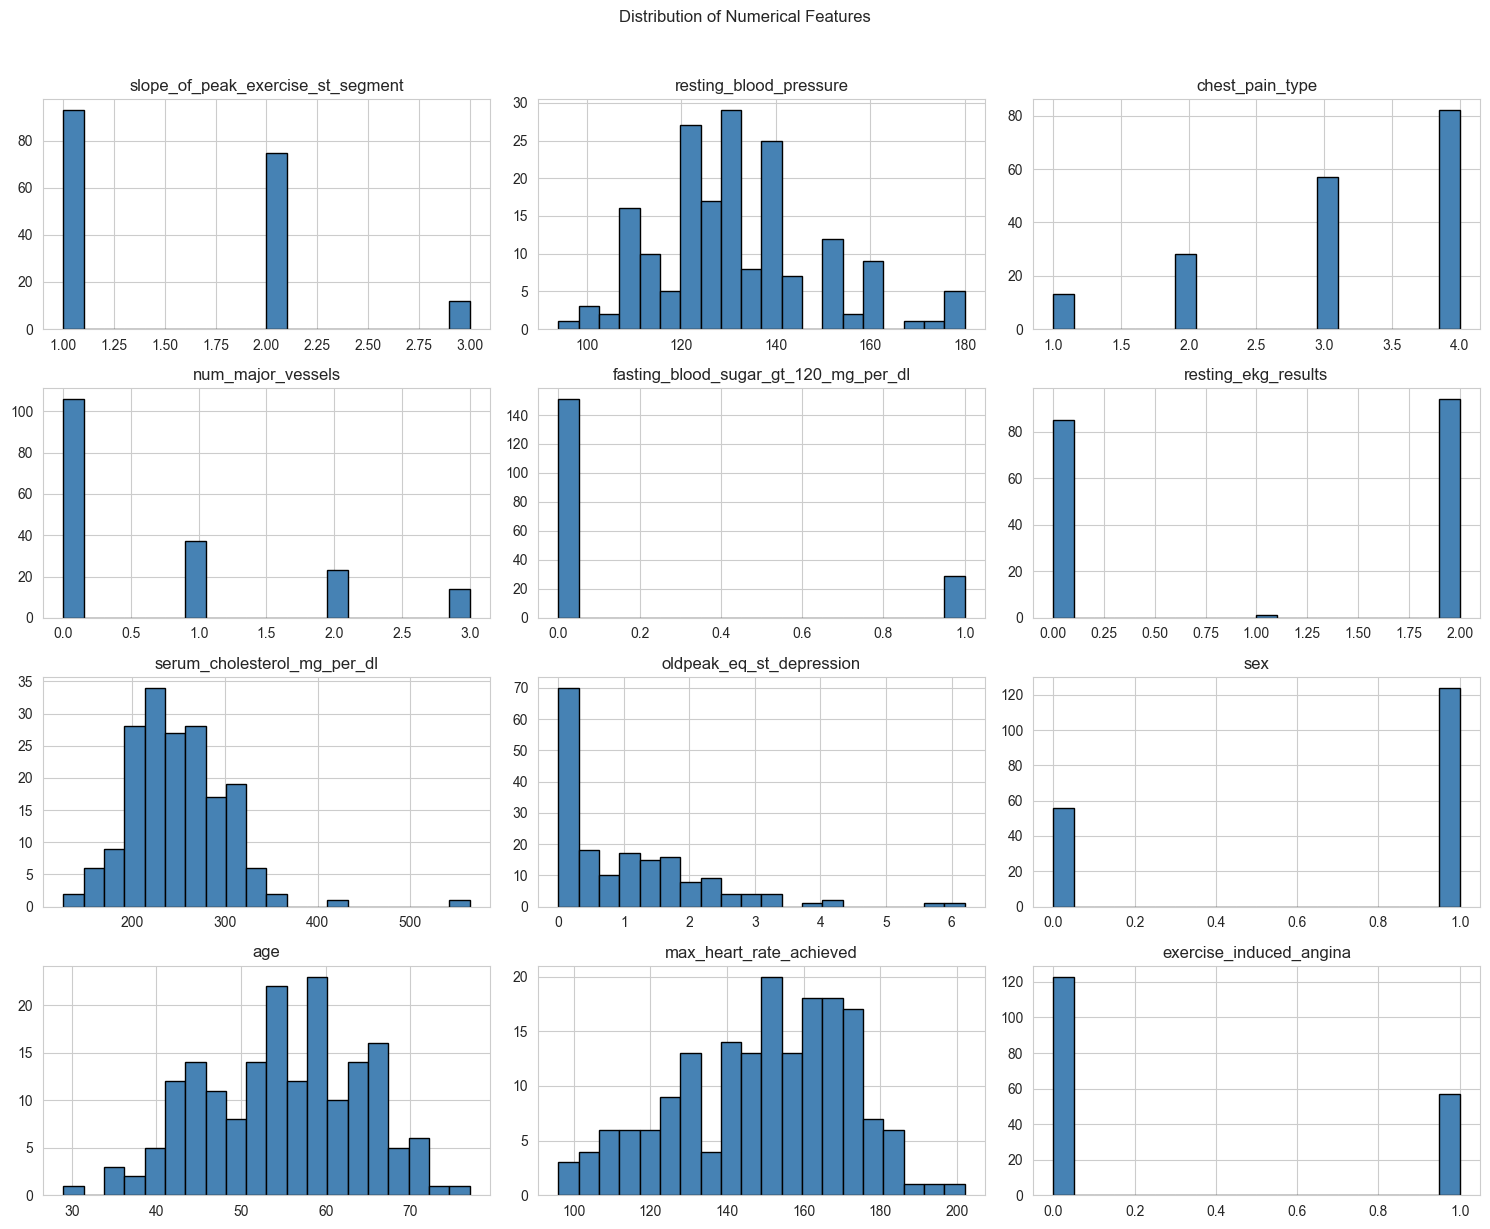

In [13]:
X_full.hist(figsize=(15, 12), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

### 2. Age vs Heart Disease

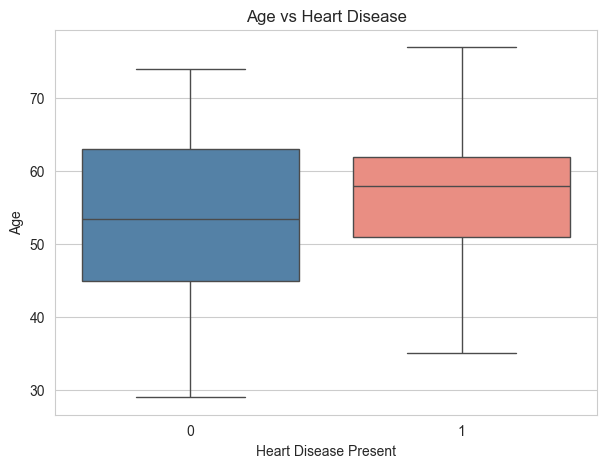

In [14]:
plt.figure(figsize=(7,5))
sns.boxplot(x="heart_disease_present", y="age", data=df, palette=["steelblue","salmon"])
plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Age")
plt.show()

### 3. Max Heart Rate Achieved vs Heart Disease

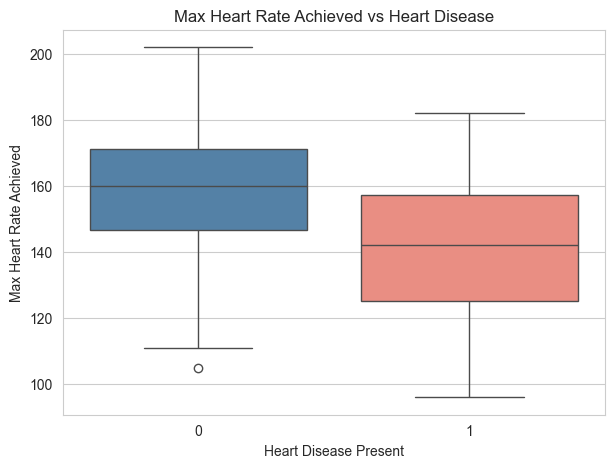

In [15]:
plt.figure(figsize=(7,5))
sns.boxplot(x="heart_disease_present", y="max_heart_rate_achieved", data=df, palette=["steelblue","salmon"])
plt.title("Max Heart Rate Achieved vs Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Max Heart Rate Achieved")
plt.show()

### 4. Serum Cholesterol vs Heart Disease

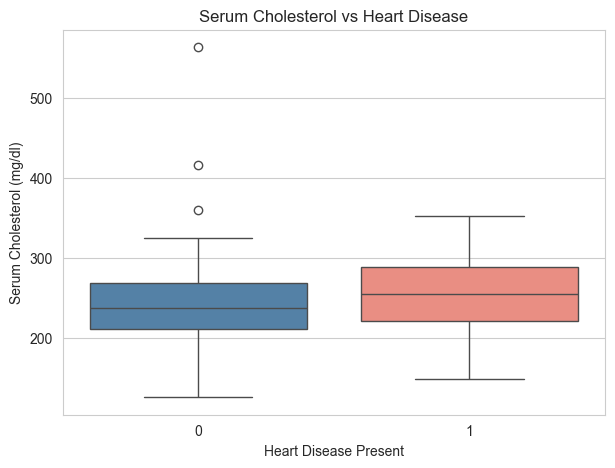

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(x="heart_disease_present", y="serum_cholesterol_mg_per_dl", data=df, palette=["steelblue","salmon"])
plt.title("Serum Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Serum Cholesterol (mg/dl)")
plt.show()

### 5. ST Depression (oldpeak) vs Heart Disease

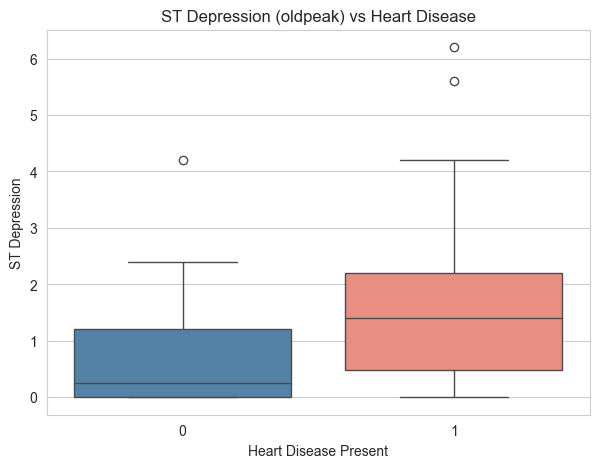

In [17]:
plt.figure(figsize=(7,5))
sns.boxplot(x="heart_disease_present", y="oldpeak_eq_st_depression", data=df, palette=["steelblue","salmon"])
plt.title("ST Depression (oldpeak) vs Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("ST Depression")
plt.show()

### 6. Chest Pain Type vs Heart Disease

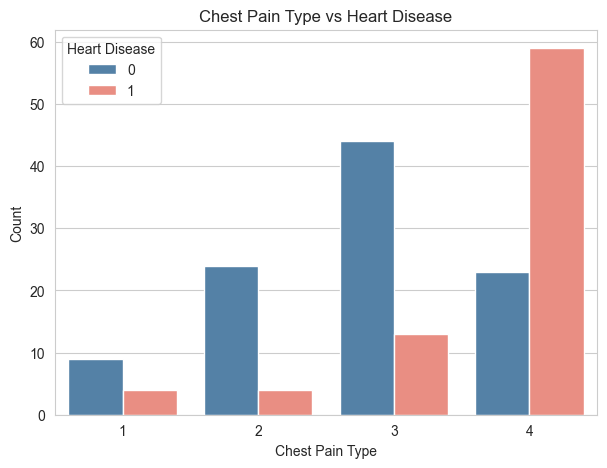

In [18]:
plt.figure(figsize=(7,5))
sns.countplot(x="chest_pain_type", hue="heart_disease_present", data=df, palette=["steelblue","salmon"])
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.legend(title="Heart Disease")
plt.show()

### 7. Thal (Thallium Stress Test) vs Heart Disease

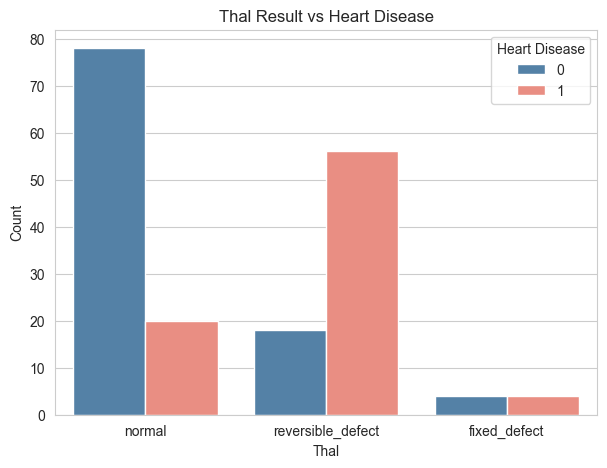

In [19]:
plt.figure(figsize=(7,5))
sns.countplot(x="thal", hue="heart_disease_present", data=df, palette=["steelblue","salmon"])
plt.title("Thal Result vs Heart Disease")
plt.xlabel("Thal")
plt.ylabel("Count")
plt.legend(title="Heart Disease")
plt.show()

### 8. Exercise Induced Angina vs Heart Disease

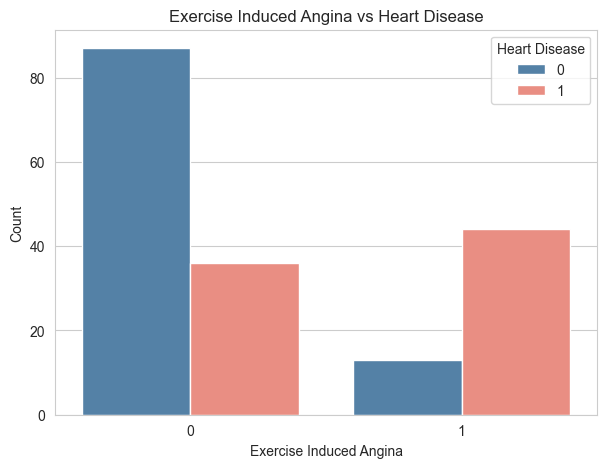

In [20]:
plt.figure(figsize=(7,5))
sns.countplot(x="exercise_induced_angina", hue="heart_disease_present", data=df, palette=["steelblue","salmon"])
plt.title("Exercise Induced Angina vs Heart Disease")
plt.xlabel("Exercise Induced Angina")
plt.ylabel("Count")
plt.legend(title="Heart Disease")
plt.show()

### EDA Findings

The visual analysis suggests that several variables show different distributions across the two target classes. In particular, `oldpeak_eq_st_depression` and `max_heart_rate_achieved` show noticeable differences between patients with and without the target condition. Age also shows some separation between the groups.

Categorical plots for chest-pain type, `thal`, and exercise-induced angina show that the proportion of heart-disease-positive observations varies across categories. These patterns indicate potentially useful predictive signal, but **they should not be interpreted as causal relationships**.

Because the dataset is small, individual observations can have a noticeable effect on the visual patterns. The EDA is therefore used to guide modelling rather than to claim clinical conclusions.

### 9. Correlation Heatmap

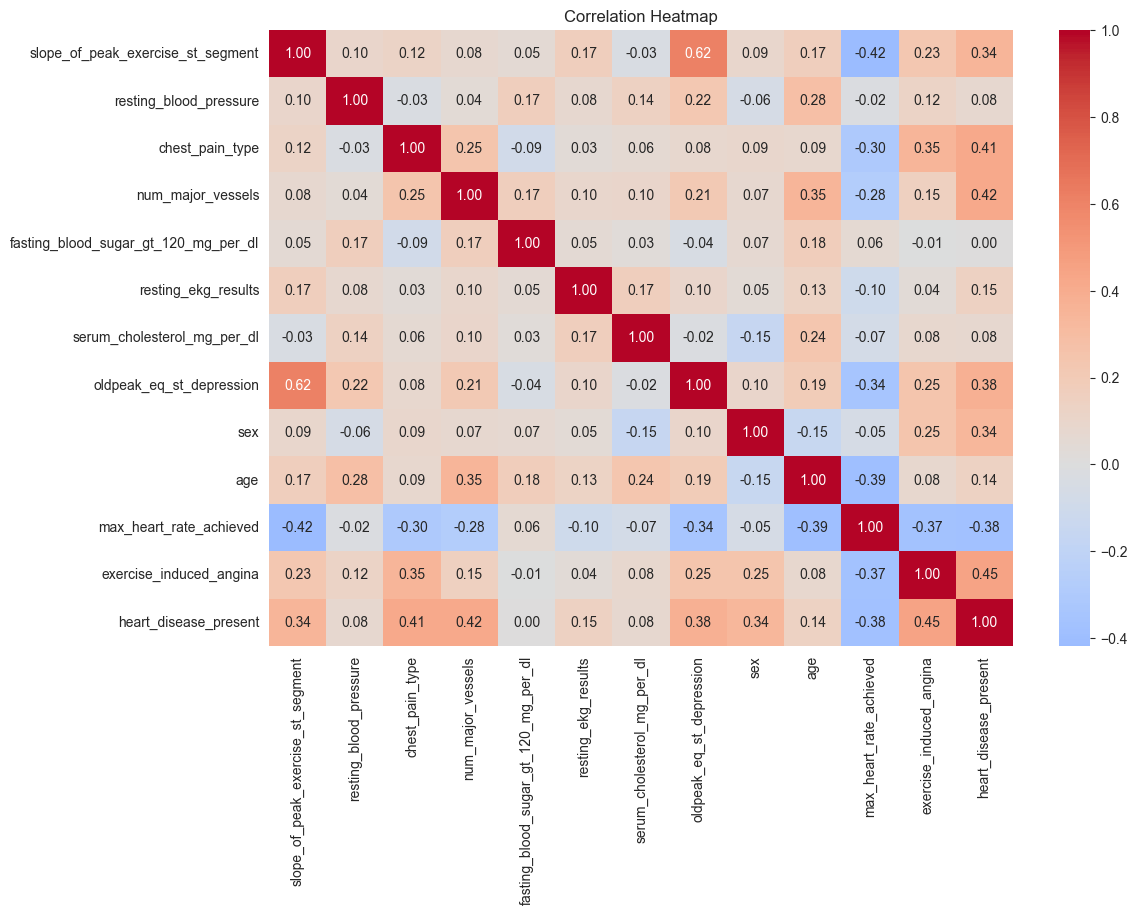

In [21]:
numeric_df = df.drop(columns=["patient_id"]).select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Findings

The correlation matrix provides a first look at linear association among numeric variables. In this dataset, `num_major_vessels`, `oldpeak_eq_st_depression`, and `exercise_induced_angina` show relatively stronger positive associations with the target than many other numeric variables, while `max_heart_rate_achieved` shows a negative association.

Correlation is **not** a measure of causation and does not capture nonlinear relationships or interactions. Therefore, model-based evaluation is required before deciding which variables are useful for prediction.

# 7. Feature Engineering

The feature-engineering strategy is intentionally simple because the supplied dataset is already structured and contains no missing values.

- `patient_id` is removed because it is an identifier.
- `thal` is one-hot encoded because it is categorical.
- Numeric measurements are standardized for models that are sensitive to feature scale.
- No synthetic variables are introduced, reducing unnecessary complexity and the risk of overfitting on this small dataset.

All transformations are fitted using the training data only.

In [22]:
df_original = df.copy()
X_full["thal"].value_counts()

thal
normal               98
reversible_defect    74
fixed_defect          8
Name: count, dtype: int64

# 8. Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (144, 13)
Test shape: (36, 13)


# 9. Encoding

* One-hot encoding `thal` — fit only on the training data and apply the same transform to the test data, to avoid data leakage.

In [24]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

thal_train = encoder.fit_transform(X_train[["thal"]])
thal_test = encoder.transform(X_test[["thal"]])

thal_cols = encoder.get_feature_names_out(["thal"])
thal_train_df = pd.DataFrame(thal_train, columns=thal_cols, index=X_train.index)
thal_test_df = pd.DataFrame(thal_test, columns=thal_cols, index=X_test.index)

In [25]:
X_train = X_train.drop(columns=["thal"])
X_train = pd.concat([X_train, thal_train_df], axis=1)

X_test = X_test.drop(columns=["thal"])
X_test = pd.concat([X_test, thal_test_df], axis=1)

X_train.head()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_fixed_defect,thal_normal,thal_reversible_defect
139,1,130,2,0,0,2,219,0.0,1,44,188,0,0.0,1.0,0.0
0,1,128,2,0,0,2,308,0.0,1,45,170,0,0.0,1.0,0.0
169,2,110,1,0,0,2,211,1.8,1,64,144,1,0.0,1.0,0.0
65,1,126,4,0,0,2,282,0.0,1,35,156,1,0.0,0.0,1.0
98,1,155,3,0,0,0,269,0.8,0,65,148,0,0.0,1.0,0.0


# 10. Scaling

* Scaling the numeric features so distance/gradient-based models (SVM, Logistic Regression, KNN) are not dominated by features on larger numeric scales (e.g. cholesterol vs binary flags).

In [26]:
numerical_features = [
    "slope_of_peak_exercise_st_segment", "resting_blood_pressure", "chest_pain_type",
    "num_major_vessels", "resting_ekg_results", "serum_cholesterol_mg_per_dl",
    "oldpeak_eq_st_depression", "age", "max_heart_rate_achieved"
]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (144, 15)
Test shape: (36, 15)


# 11. Model Building

## Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]
print(y_pred_lr)

[0 1 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 1 1 0 0 1]


### Evaluate Logistic Regression

In [28]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

Accuracy: 0.833
Precision: 0.778
Recall: 0.875
F1 Score: 0.824
ROC-AUC: 0.944


### Confusion Matrix - Logistic Regression

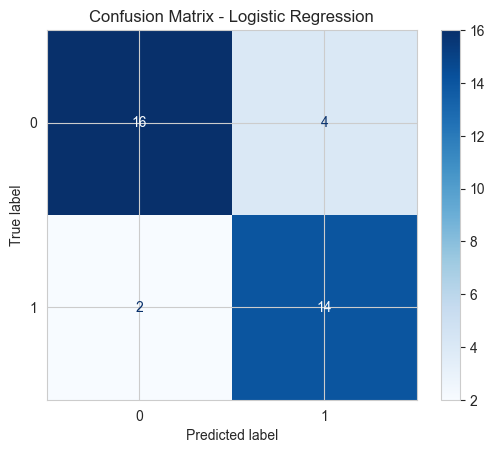

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Train Other Models

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

### Train and Evaluate All Models

In [31]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.888889,0.875000,0.8750,0.875000,0.962500
1,Gradient Boosting,0.916667,0.842105,1.0000,0.914286,0.956250
2,KNN,0.944444,0.937500,0.9375,0.937500,0.946875
3,Logistic Regression,0.833333,0.777778,0.8750,0.823529,0.943750
4,Random Forest,0.888889,0.833333,0.9375,0.882353,0.931250
5,Decision Tree,0.777778,0.785714,0.6875,0.733333,0.768750


### Compare the Models Visually

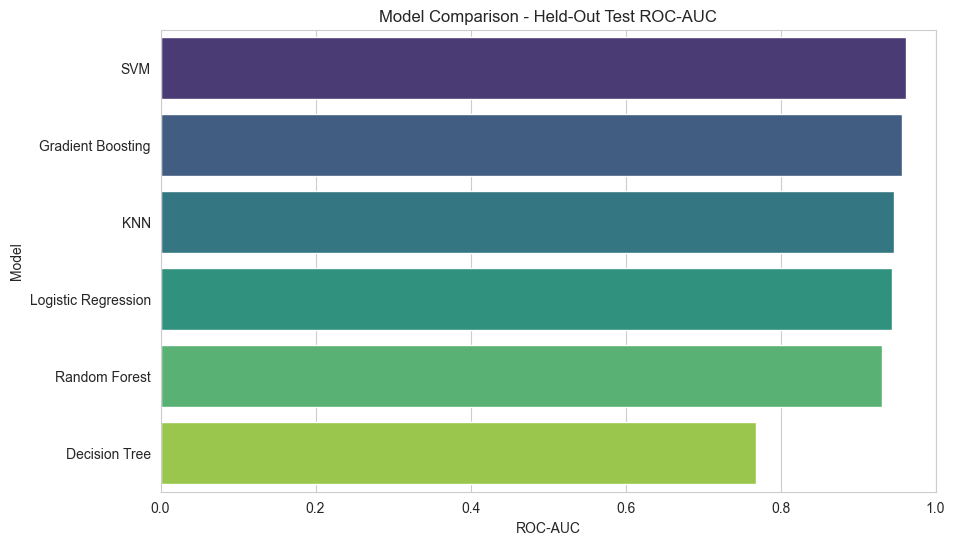

In [32]:
# Compare test-set ROC-AUC
plt.figure(figsize=(10, 6))
sns.barplot(x="ROC-AUC", y="Model", data=results_df, palette="viridis")
plt.title("Model Comparison - Held-Out Test ROC-AUC")
plt.xlim(0, 1)
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.show()

# 12. Cross-Validation

A single 20% test split contains only **36 patients**, so its metrics can vary substantially with the selected split. To obtain a more stable model comparison, 5-fold **StratifiedKFold** cross-validation is performed on the training set.

The folds preserve the target-class proportions as far as possible. The primary comparison metric is **ROC-AUC**, while Accuracy, Precision, Recall and F1-score are also reported.

For this healthcare screening problem, Recall is especially important because a false negative means that a patient with heart disease is predicted as not having the condition. However, ROC-AUC is used for model selection here to compare ranking/discrimination performance without committing prematurely to one probability threshold.

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC-AUC": "roc_auc"
}

In [34]:
cv_results = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "Recall": scores["test_Recall"].mean(),
        "F1 Score": scores["test_F1"].mean(),
        "ROC-AUC": scores["test_ROC-AUC"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
cv_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.833498,0.871403,0.764103,0.802230,0.874038
1,SVM,0.826601,0.864813,0.750000,0.793794,0.869071
2,Random Forest,0.812315,0.821818,0.748718,0.778160,0.865505
3,Gradient Boosting,0.777833,0.736685,0.798718,0.759958,0.861138
4,KNN,0.812808,0.826944,0.735897,0.769692,0.831170
5,Decision Tree,0.763300,0.714448,0.797436,0.748263,0.767468


### Select the Best Model

In [35]:
best_model_name = cv_results_df.iloc[0]["Model"]
print("Best model based on 5-fold cross-validated ROC-AUC:", best_model_name)

Best model based on 5-fold cross-validated ROC-AUC: Logistic Regression


# 13. Hyperparameter Tuning

The model selected by cross-validation is tuned using `GridSearchCV`. The search optimizes **ROC-AUC** using the same 5-fold stratified cross-validation strategy.

This step searches a predefined parameter grid rather than changing the model manually after seeing the test-set results. The held-out test set remains untouched until the final evaluation.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"]
    },
    "SVM": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "linear"]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200, 300],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.01, 0.05, 0.1]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"]
    },
    "Decision Tree": {
        "max_depth": [3, 5, 7, None],
        "min_samples_leaf": [1, 2, 4]
    }
}

base_model = models[best_model_name]
param_grid = param_grids[best_model_name]

grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Tuned model:", best_model_name)
print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))

Tuned model: Logistic Regression
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.879


### Evaluate the Tuned Model on the Test Set

In [37]:
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1 Score": f1_score(y_test, y_pred_final),
    "ROC-AUC": roc_auc_score(y_test, y_prob_final)
}

for metric, value in final_metrics.items():
    print(f"{metric}: {value:.3f}")

Accuracy: 0.833
Precision: 0.812
Recall: 0.812
F1 Score: 0.812
ROC-AUC: 0.934


### Confusion Matrix - Tuned Final Model

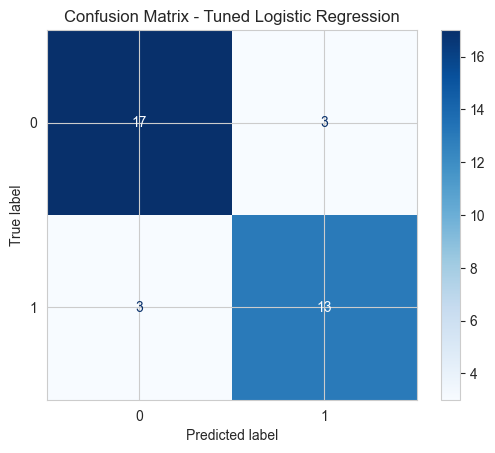

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap="Blues")
plt.title(f"Confusion Matrix - Tuned {best_model_name}")
plt.show()

### ROC Curve - Tuned Final Model

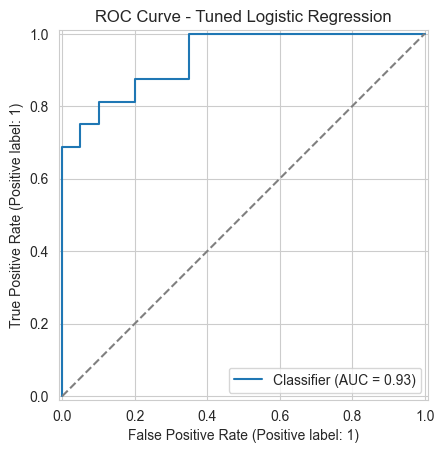

In [39]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob_final)
plt.title(f"ROC Curve - Tuned {best_model_name}")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.show()

# 14. Feature Importance / Model Interpretability

Permutation importance is calculated on the held-out test set using ROC-AUC as the scoring metric. It measures how much model performance changes when a feature's values are randomly permuted.

A positive importance indicates that the model's ROC-AUC decreased when that feature was disrupted, suggesting useful predictive information. Importance should be interpreted as **predictive contribution, not causation or clinical importance**. With only 36 test observations, these estimates can also be noisy.

In [40]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, scoring="roc_auc"
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_result.importances_mean
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
3,num_major_vessels,0.048125
7,oldpeak_eq_st_depression,0.028437
14,thal_reversible_defect,0.015625
2,chest_pain_type,0.015000
11,exercise_induced_angina,0.011875
0,slope_of_peak_exercise_st_segment,0.011562
8,sex,0.009062
13,thal_normal,0.008437
1,resting_blood_pressure,0.002812
4,fasting_blood_sugar_gt_120_mg_per_dl,0.000312


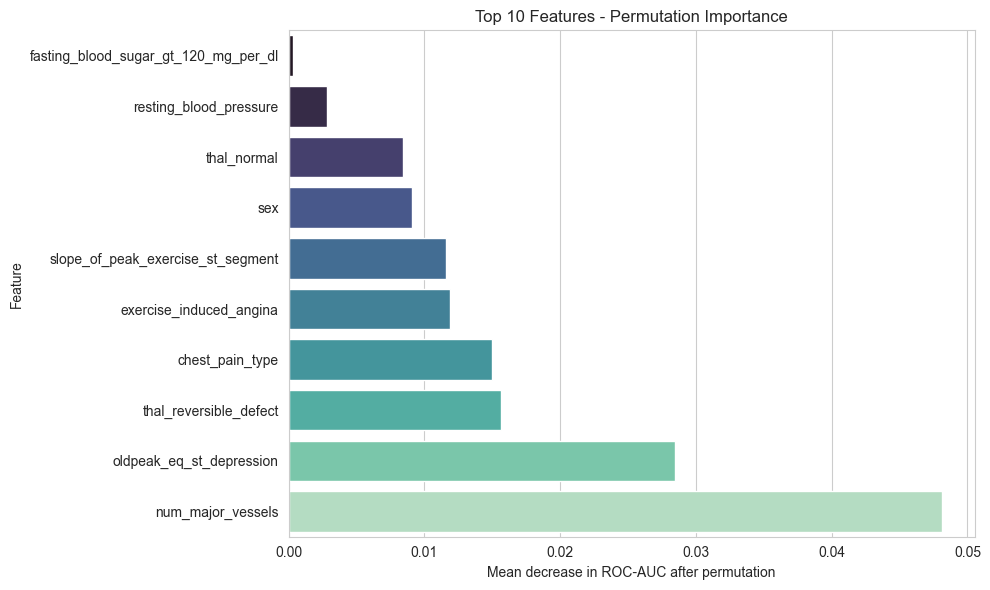

In [41]:
top_n = 10
plot_df = feature_importance.head(top_n).sort_values("Importance")

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=plot_df, palette="mako")
plt.title(f"Top {top_n} Features - Permutation Importance")
plt.xlabel("Mean decrease in ROC-AUC after permutation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 15. Threshold Analysis for Screening

The default classifier threshold is 0.50. In a healthcare screening context, it is useful to examine whether a different threshold changes the balance between Recall and Precision.

**Important:** the threshold comparison below is exploratory. A clinical threshold must be selected using validation data and an agreed cost/benefit framework, not by optimizing the held-out test set.

In [42]:
from sklearn.metrics import classification_report, precision_recall_curve

print("Classification Report - Final Tuned Model (threshold = 0.50)\n")
print(classification_report(y_test, y_pred_final, target_names=["No Heart Disease", "Heart Disease"], digits=3))

# Additional screening metric: specificity / true-negative rate
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0
sensitivity = tp / (tp + fn) if (tp + fn) else 0

print(f"Sensitivity / Recall: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")

Classification Report - Final Tuned Model (threshold = 0.50)

                  precision    recall  f1-score   support

No Heart Disease      0.850     0.850     0.850        20
   Heart Disease      0.812     0.812     0.812        16

        accuracy                          0.833        36
       macro avg      0.831     0.831     0.831        36
    weighted avg      0.833     0.833     0.833        36

Sensitivity / Recall: 0.812
Specificity: 0.850


In [43]:
threshold_rows = []
for threshold in np.arange(0.30, 0.71, 0.05):
    pred_t = (y_prob_final >= threshold).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, pred_t).ravel()
    threshold_rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(y_test, pred_t, zero_division=0),
        "Recall": recall_score(y_test, pred_t, zero_division=0),
        "F1 Score": f1_score(y_test, pred_t, zero_division=0),
        "Specificity": tn_t / (tn_t + fp_t) if (tn_t + fp_t) else 0
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.style.format({
    "Precision": "{:.3f}", "Recall": "{:.3f}",
    "F1 Score": "{:.3f}", "Specificity": "{:.3f}"
}))

,Threshold,Precision,Recall,F1 Score,Specificity
0,0.300000,0.667,1.000,0.800,0.600
1,0.350000,0.682,0.938,0.789,0.650
2,0.400000,0.700,0.875,0.778,0.700
3,0.450000,0.778,0.875,0.824,0.800
4,0.500000,0.812,0.812,0.812,0.850
5,0.550000,0.812,0.812,0.812,0.850
6,0.600000,0.857,0.750,0.800,0.900
7,0.650000,0.857,0.750,0.800,0.900
8,0.700000,0.857,0.750,0.800,0.900


### Threshold interpretation

Lowering the threshold generally increases the number of patients flagged as positive, which can improve Recall but may reduce Precision/Specificity. For this reason, the hospital should define the acceptable false-negative rate first and then choose a threshold using validation data.

No threshold from this small held-out test set is recommended for clinical deployment.

# 16. Cross-Validation Model Comparison Visualization

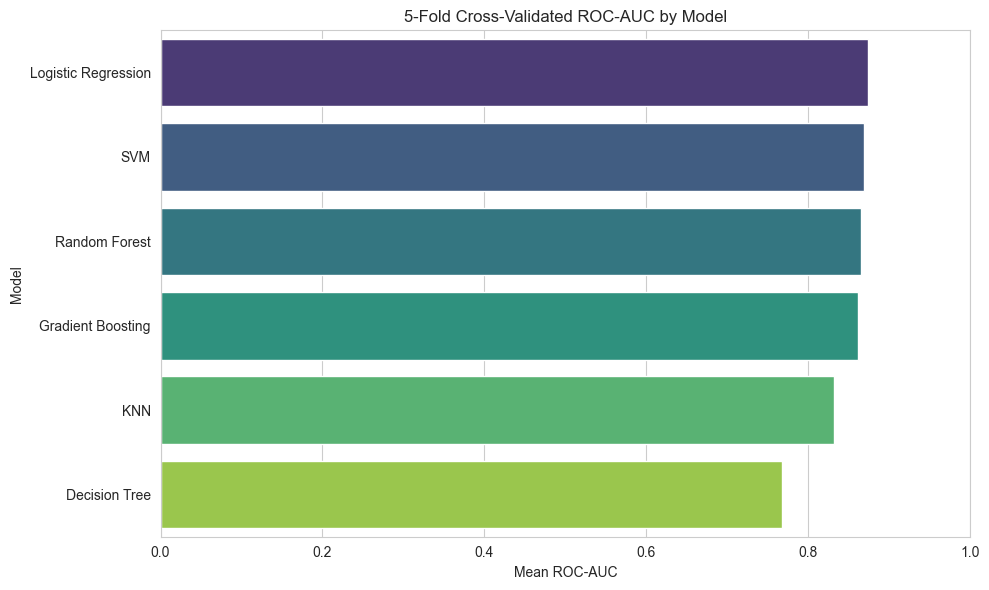

In [44]:
cv_plot_df = cv_results_df.sort_values("ROC-AUC", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="ROC-AUC", y="Model", data=cv_plot_df, palette="viridis")
plt.title("5-Fold Cross-Validated ROC-AUC by Model")
plt.xlim(0, 1)
plt.xlabel("Mean ROC-AUC")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# 17. Final Deliverables and Reproducibility

The final model artifacts are saved after training:

- `heart_disease_model.pkl` — tuned final estimator
- `model_features.pkl` — feature order expected by the estimator
- `scaler.pkl` — fitted numerical scaler
- `thal_encoder.pkl` — fitted categorical encoder

The preprocessing objects must be used in exactly the same order during inference. Because the current workflow uses a small academic dataset, these artifacts should be treated as a project prototype rather than a clinically deployable package.
- `model_artifact_manifest.pkl` — records the selected model and evaluation metadata.


# 18. Save the Final Model

In [45]:
import joblib

joblib.dump(best_model, "heart_disease_model.pkl")
joblib.dump(list(X_train.columns), "model_features.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "thal_encoder.pkl")

artifact_manifest = {
    "model": "heart_disease_model.pkl",
    "features": "model_features.pkl",
    "scaler": "scaler.pkl",
    "encoder": "thal_encoder.pkl",
    "model_name": best_model_name,
    "selection_metric": "5-fold cross-validated ROC-AUC",
    "test_metrics": final_metrics
}
joblib.dump(artifact_manifest, "model_artifact_manifest.pkl")

print("Final model artifacts saved successfully:")
for key, filename in artifact_manifest.items():
    print(f"  {key}: {filename}")
print(f"\nModel: {best_model_name} (tuned)")
print(f"Number of encoded features: {len(X_train.columns)}")

Final model artifacts saved successfully:
  model: heart_disease_model.pkl
  features: model_features.pkl
  scaler: scaler.pkl
  encoder: thal_encoder.pkl
  model_name: Logistic Regression
  selection_metric: 5-fold cross-validated ROC-AUC
  test_metrics: {'Accuracy': 0.8333333333333334, 'Precision': 0.8125, 'Recall': 0.8125, 'F1 Score': 0.8125, 'ROC-AUC': 0.934375}

Model: Logistic Regression (tuned)
Number of encoded features: 15


# 19. Final Report

## Model Comparison Report

In [46]:
print("=" * 75)
print("FINAL MODEL COMPARISON REPORT")
print("=" * 75)
print(f"Dataset size: {df.shape[0]} patients")
print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Encoded feature count: {X_train.shape[1]}")

print("\n1) Held-out test-set performance")
display(results_df.round(3))

print("2) 5-fold cross-validated performance")
display(cv_results_df.round(3))

print(f"3) Selected model: {best_model_name}")
print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

print("\n4) Final tuned model - held-out test set")
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.3f}")

print("\nInterpretation:")
print("The model was selected using cross-validation rather than the single 36-patient test split.")
print("The final model is a decision-support/triage prototype, not a standalone medical diagnostic system.")

FINAL MODEL COMPARISON REPORT
Dataset size: 180 patients
Training rows: 144 | Test rows: 36
Encoded feature count: 15

1) Held-out test-set performance


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.889,0.875,0.875,0.875,0.963
1,Gradient Boosting,0.917,0.842,1.000,0.914,0.956
2,KNN,0.944,0.938,0.938,0.938,0.947
3,Logistic Regression,0.833,0.778,0.875,0.824,0.944
4,Random Forest,0.889,0.833,0.938,0.882,0.931
5,Decision Tree,0.778,0.786,0.688,0.733,0.769


2) 5-fold cross-validated performance


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.833,0.871,0.764,0.802,0.874
1,SVM,0.827,0.865,0.750,0.794,0.869
2,Random Forest,0.812,0.822,0.749,0.778,0.866
3,Gradient Boosting,0.778,0.737,0.799,0.760,0.861
4,KNN,0.813,0.827,0.736,0.770,0.831
5,Decision Tree,0.763,0.714,0.797,0.748,0.767


3) Selected model: Logistic Regression
Best hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validated ROC-AUC: 0.879

4) Final tuned model - held-out test set
Accuracy: 0.833
Precision: 0.812
Recall: 0.812
F1 Score: 0.812
ROC-AUC: 0.934

Interpretation:
The model was selected using cross-validation rather than the single 36-patient test split.
The final model is a decision-support/triage prototype, not a standalone medical diagnostic system.


**Key observations:**
- The single 36-patient test-set ranking and the 5-fold cross-validated ranking can differ — this is expected with such a small dataset, since one or two patients flipping outcome can swing test-set metrics noticeably. **Cross-validation was used as the deciding factor** when selecting the best model, since it averages over 5 folds and is far less sensitive to any single split.
- The selected model was then tuned with `GridSearchCV`, and its final performance was confirmed on the held-out test set (see printed metrics above).
- Permutation importance on the tuned model (see Feature Importance section) highlighted clinically meaningful features (ST depression, number of major vessels, exercise-induced angina) among the strongest predictors — a good sanity check that the model is learning genuine medical signal rather than noise.

## Challenges Faced and Techniques Used

### 1. Small dataset
The dataset contains only **180 observations**, with 144 used for training and 36 for the final test. A small test set makes single-split metrics unstable.

**Technique:** 5-fold stratified cross-validation was added and used as the primary model-comparison mechanism. The final test set was retained for an independent end-stage check.

### 2. Categorical variable
`thal` is categorical and cannot be passed directly to the selected scikit-learn estimators as text.

**Technique:** One-hot encoding with `handle_unknown="ignore"`. The encoder is fitted only on the training data and then applied to the test data.

### 3. Different feature scales
Features such as cholesterol, blood pressure and age have very different numeric ranges, while several other variables are binary or low-cardinality.

**Technique:** `StandardScaler` is fitted on training data only. This is particularly useful for Logistic Regression, KNN and SVM.

### 4. Model-selection uncertainty
KNN performs very strongly on the single hold-out test set, but its cross-validated performance is lower. This demonstrates why relying only on one test split can be misleading for a small dataset.

**Technique:** compare both hold-out metrics and cross-validated metrics, then use cross-validation to choose the model before tuning.

### 5. Healthcare error costs
Accuracy alone does not describe the cost of false negatives and false positives. Missing a true positive case can be particularly undesirable in a screening workflow.

**Technique:** report Precision, Recall, F1 and ROC-AUC; additionally inspect the confusion matrix and evaluate alternative probability thresholds.

### 6. Interpretability
A machine-learning model can identify predictive patterns without proving that a feature causes disease.

**Technique:** use permutation importance for model-agnostic interpretation and explicitly avoid causal claims.

## Suggestions to the Hospital

The following recommendations are based on the modelling results and are intended for **decision support / triage**, not autonomous diagnosis.

1. **Use model probability for prioritization.** Instead of treating the output as a medical diagnosis, use the predicted probability to help identify patients who may warrant earlier review.

2. **Prioritize sensitivity for screening.** Because false negatives can be costly in a screening setting, the hospital should select the operating threshold using validation data and an agreed clinical cost trade-off.

3. **Create a human-in-the-loop workflow.** A high-risk prediction should trigger review of symptoms, history and relevant clinical investigations by qualified healthcare professionals. The model should support—not replace—clinical judgment.

4. **Use risk bands only after validation.** Low-, medium- and high-risk categories can be created from predicted probabilities, but the thresholds should be validated on a larger clinical dataset rather than chosen arbitrarily from this 180-row academic dataset.

5. **Monitor model performance after deployment.** Track sensitivity/recall, specificity, precision, calibration, false-negative rate and changes in the incoming patient population.

6. **Collect more representative data.** A larger dataset with diverse patient populations would reduce uncertainty and improve confidence in generalization.

7. **Perform external validation before clinical use.** The model should be evaluated on an independent dataset from a different time period and/or clinical setting before being considered for real-world deployment.

8. **Schedule appropriate follow-up for at-risk patients.** Model output can be incorporated into an existing screening workflow, but follow-up intervals and interventions should be determined by clinical protocols rather than by the model alone.

## Conclusion

This project developed an end-to-end machine-learning workflow for predicting the presence of heart disease from cardiovascular measurements. The process included data loading and merging, data-quality checks, exploratory data analysis, categorical encoding, feature scaling, six classification algorithms, 5-fold stratified cross-validation, hyperparameter tuning, final test evaluation, confusion-matrix analysis, ROC analysis and model interpretation.

The single hold-out test set produced a different ranking from cross-validation, which is expected given the small sample size. The final production candidate was therefore selected using cross-validated performance rather than choosing the model solely because it achieved the highest score on the 36-patient test split. The tuned Logistic Regression model achieved **83.3% accuracy and 0.934 ROC-AUC on the held-out test set** in the current notebook run.

The model is best positioned as an **academic prototype and clinical decision-support/triage candidate**, not as a standalone diagnostic system. Before real-world use, the workflow should undergo external validation, probability calibration, threshold optimization with emphasis on clinically appropriate sensitivity, fairness/generalization checks, and clinical governance.

### Final project takeaway

**The main value of this project is not a single accuracy number; it is a reproducible modelling workflow that compares algorithms, quantifies uncertainty through cross-validation, considers healthcare-specific error costs, and clearly defines the limitations of the available data.**